In [3]:
import pandas as pd

# Load the 4 FORESIGHT datasets
sales = pd.read_csv("../data/raw/sales_daily.csv")
sku_master = pd.read_csv("../data/raw/sku_master.csv")
inventory = pd.read_csv("../data/raw/inventory_snapshots.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")

print("Sales:", sales.shape)
print("SKU Master:", sku_master.shape)
print("Inventory:", inventory.shape)
print("Calendar:", calendar.shape)

Sales: (36550, 6)
SKU Master: (50, 8)
Inventory: (4800, 8)
Calendar: (731, 11)


In [4]:
# Check missing values in each dataset

print("SALES MISSING VALUES")
print(sales.isnull().sum())

print("\nSKU MASTER MISSING VALUES")
print(sku_master.isnull().sum())

print("\nINVENTORY MISSING VALUES")
print(inventory.isnull().sum())

print("\nCALENDAR MISSING VALUES")
print(calendar.isnull().sum())

SALES MISSING VALUES
Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

SKU MASTER MISSING VALUES
SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

INVENTORY MISSING VALUES
Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

CALENDAR MISSING VALUES
date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64


In [5]:
# Check duplicate rows

print("Duplicate rows:")
print("Sales:", sales.duplicated().sum())
print("SKU Master:", sku_master.duplicated().sum())
print("Inventory:", inventory.duplicated().sum())
print("Calendar:", calendar.duplicated().sum())


# Check data types

print("\n--- SALES DATA TYPES ---")
print(sales.dtypes)

print("\n--- SKU MASTER DATA TYPES ---")
print(sku_master.dtypes)

print("\n--- INVENTORY DATA TYPES ---")
print(inventory.dtypes)

print("\n--- CALENDAR DATA TYPES ---")
print(calendar.dtypes)

Duplicate rows:
Sales: 0
SKU Master: 0
Inventory: 0
Calendar: 0

--- SALES DATA TYPES ---
Date              str
SKU               str
Units_Sold      int64
Revenue       float64
Price         float64
Promotion       int64
dtype: object

--- SKU MASTER DATA TYPES ---
SKU                          str
Product_Name                 str
Category                     str
Subcategory                  str
Launch_Date                  str
Cost_Price               float64
Selling_Price            float64
Gross_Margin_Per_Unit    float64
dtype: object

--- INVENTORY DATA TYPES ---
Snapshot_Date          str
SKU                    str
Current_Stock        int64
On_Order             int64
Lead_Time_Days       int64
Safety_Stock         int64
Reorder_Point        int64
Inventory_Value    float64
dtype: object

--- CALENDAR DATA TYPES ---
date                 str
year               int64
month              int64
quarter              str
week               int64
day_of_week          str
is_weekend      

In [13]:
# Show the first 5 rows of each dataset

print("===== SALES =====")
display(sales.head())

print("\n===== SKU MASTER =====")
display(sku_master.head())

print("\n===== INVENTORY =====")
display(inventory.head())

print("\n===== CALENDAR =====")
display(calendar.head())

===== SALES =====


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0



===== SKU MASTER =====


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,SKU003,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,SKU004,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,SKU005,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59



===== INVENTORY =====


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89



===== CALENDAR =====


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


In [15]:
# ============================================
# STEP 3.4 - DATE CLEANING AND DATE RANGE CHECK
# ============================================

# Convert Sales date
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

# Convert Inventory date
inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"],
    errors="coerce"
)

# Find the date column in Calendar automatically
calendar_date_column = None

for column in calendar.columns:
    if column.lower().strip() in ["date", "calendar_date"]:
        calendar_date_column = column
        break

# If a date column was found, convert it
if calendar_date_column:
    calendar[calendar_date_column] = pd.to_datetime(
        calendar[calendar_date_column],
        errors="coerce"
    )
    print("Calendar date column found:", calendar_date_column)
else:
    print("WARNING: No Date column found in calendar.")
    print("Calendar columns are:")
    print(calendar.columns.tolist())


# ============================================
# DATE RANGES
# ============================================

print("\n========== SALES ==========")
print("Start:", sales["Date"].min())
print("End  :", sales["Date"].max())

print("\n========== INVENTORY ==========")
print("Start:", inventory["Snapshot_Date"].min())
print("End  :", inventory["Snapshot_Date"].max())

if calendar_date_column:
    print("\n========== CALENDAR ==========")
    print("Start:", calendar[calendar_date_column].min())
    print("End  :", calendar[calendar_date_column].max())


# ============================================
# CHECK FOR INVALID / MISSING DATES
# ============================================

print("\n========== INVALID / MISSING DATES ==========")

print("Sales:", sales["Date"].isna().sum())

print(
    "Inventory:",
    inventory["Snapshot_Date"].isna().sum()
)

if calendar_date_column:
    print(
        "Calendar:",
        calendar[calendar_date_column].isna().sum()
    )

Calendar date column found: date

========== SALES ==========
Start: 2024-01-01 00:00:00
End  : 2025-12-31 00:00:00

========== INVENTORY ==========
Start: 2024-01-01 00:00:00
End  : 2025-12-01 00:00:00

========== CALENDAR ==========
Start: 2024-01-01 00:00:00
End  : 2025-12-31 00:00:00

========== INVALID / MISSING DATES ==========
Sales: 0
Inventory: 0
Calendar: 0


In [16]:
# ============================================
# STEP 3.5 - CHECK SKU SALES COVERAGE
# ============================================

# Number of unique SKUs
sales_skus = sales["SKU"].nunique()
master_skus = sku_master["SKU"].nunique()

print("Unique SKUs in Sales Data :", sales_skus)
print("Unique SKUs in SKU Master :", master_skus)


# Check which SKUs are in Sales but not in SKU Master
sales_sku_set = set(sales["SKU"].unique())
master_sku_set = set(sku_master["SKU"].unique())

missing_from_master = sales_sku_set - master_sku_set
missing_from_sales = master_sku_set - sales_sku_set

print("\nSKUs in Sales but NOT in SKU Master:")
print(missing_from_master)

print("\nSKUs in SKU Master but NOT in Sales:")
print(missing_from_sales)


# ============================================
# SALES RECORDS PER SKU
# ============================================

sales_per_sku = sales.groupby("SKU").size()

print("\n========== SALES RECORDS PER SKU ==========")
print(sales_per_sku.describe())


# Show SKUs with the fewest sales records
print("\nSKUs with the fewest sales records:")
print(sales_per_sku.sort_values().head(10))


# Show SKUs with the most sales records
print("\nSKUs with the most sales records:")
print(sales_per_sku.sort_values(ascending=False).head(10))

Unique SKUs in Sales Data : 50
Unique SKUs in SKU Master : 50

SKUs in Sales but NOT in SKU Master:
set()

SKUs in SKU Master but NOT in Sales:
set()

========== SALES RECORDS PER SKU ==========
count     50.0
mean     731.0
std        0.0
min      731.0
25%      731.0
50%      731.0
75%      731.0
max      731.0
dtype: float64

SKUs with the fewest sales records:
SKU
SKU001    731
SKU002    731
SKU003    731
SKU004    731
SKU005    731
SKU006    731
SKU007    731
SKU008    731
SKU009    731
SKU010    731
dtype: int64

SKUs with the most sales records:
SKU
SKU001    731
SKU002    731
SKU003    731
SKU004    731
SKU005    731
SKU006    731
SKU007    731
SKU008    731
SKU009    731
SKU010    731
dtype: int64


In [17]:
# STEP 3.6 - SALES & INVENTORY CONSISTENCY

# 1. Check SKU coverage in Inventory
sales_skus = set(sales["SKU"].unique())
inventory_skus = set(inventory["SKU"].unique())

print("SKUs in Sales:", len(sales_skus))
print("SKUs in Inventory:", len(inventory_skus))

print("\nSKUs in Sales but NOT in Inventory:")
print(sales_skus - inventory_skus)

print("\nSKUs in Inventory but NOT in Sales:")
print(inventory_skus - sales_skus)


# ============================================
# 2. Check inventory numeric columns
# ============================================

inventory_columns = [
    "Current_Stock",
    "On_Order",
    "Lead_Time_Days",
    "Safety_Stock",
    "Reorder_Point",
    "Inventory_Value"
]

print("\n========== INVENTORY NEGATIVE VALUES ==========")

for column in inventory_columns:
    negative_count = (inventory[column] < 0).sum()
    print(column, ":", negative_count)


# ============================================
# 3. Check sales numeric columns
# ============================================

sales_columns = [
    "Units_Sold",
    "Revenue",
    "Price"
]

print("\n========== SALES NEGATIVE VALUES ==========")

for column in sales_columns:
    negative_count = (sales[column] < 0).sum()
    print(column, ":", negative_count)


# ============================================
# 4. Check Promotion values
# ============================================

print("\n========== PROMOTION VALUES ==========")
print(sales["Promotion"].value_counts(dropna=False))


# ============================================
# 5. Basic inventory statistics
# ============================================

print("\n========== INVENTORY SUMMARY ==========")
print(inventory[inventory_columns].describe())

SKUs in Sales: 50
SKUs in Inventory: 200

SKUs in Sales but NOT in Inventory:
set()

SKUs in Inventory but NOT in Sales:
{'SKU075', 'SKU103', 'SKU094', 'SKU057', 'SKU104', 'SKU089', 'SKU109', 'SKU116', 'SKU110', 'SKU082', 'SKU126', 'SKU197', 'SKU124', 'SKU090', 'SKU136', 'SKU073', 'SKU052', 'SKU118', 'SKU179', 'SKU064', 'SKU140', 'SKU152', 'SKU054', 'SKU138', 'SKU070', 'SKU193', 'SKU086', 'SKU077', 'SKU181', 'SKU122', 'SKU101', 'SKU170', 'SKU080', 'SKU115', 'SKU069', 'SKU111', 'SKU123', 'SKU153', 'SKU177', 'SKU125', 'SKU188', 'SKU098', 'SKU134', 'SKU087', 'SKU061', 'SKU190', 'SKU172', 'SKU072', 'SKU059', 'SKU187', 'SKU186', 'SKU195', 'SKU132', 'SKU185', 'SKU150', 'SKU053', 'SKU096', 'SKU063', 'SKU158', 'SKU071', 'SKU145', 'SKU160', 'SKU196', 'SKU093', 'SKU182', 'SKU120', 'SKU097', 'SKU191', 'SKU148', 'SKU154', 'SKU117', 'SKU119', 'SKU164', 'SKU079', 'SKU106', 'SKU107', 'SKU065', 'SKU162', 'SKU083', 'SKU167', 'SKU056', 'SKU147', 'SKU194', 'SKU189', 'SKU100', 'SKU200', 'SKU130', 'SKU163'

In [18]:
# ============================================
# STEP 4 - DATA QUALITY SUMMARY
# ============================================

print("==========================================")
print("       PROJECT FORESIGHT")
print("       DATA QUALITY SUMMARY")
print("==========================================")

print("\n1. DATASET SIZES")
print("------------------------------------------")
print("Sales records      :", len(sales))
print("SKU Master records :", len(sku_master))
print("Inventory records  :", len(inventory))
print("Calendar records   :", len(calendar))

print("\n2. UNIQUE SKUs")
print("------------------------------------------")
print("Sales SKUs         :", sales["SKU"].nunique())
print("SKU Master SKUs    :", sku_master["SKU"].nunique())
print("Inventory SKUs     :", inventory["SKU"].nunique())

print("\n3. DUPLICATE ROWS")
print("------------------------------------------")
print("Sales              :", sales.duplicated().sum())
print("SKU Master         :", sku_master.duplicated().sum())
print("Inventory          :", inventory.duplicated().sum())
print("Calendar           :", calendar.duplicated().sum())

print("\n4. MISSING VALUES")
print("------------------------------------------")
print("Sales missing values:")
print(sales.isnull().sum())

print("\nInventory missing values:")
print(inventory.isnull().sum())

print("\nSKU Master missing values:")
print(sku_master.isnull().sum())

print("\nCalendar missing values:")
print(calendar.isnull().sum())

print("\n==========================================")
print("Data quality inspection completed.")
print("==========================================")

       PROJECT FORESIGHT
       DATA QUALITY SUMMARY

1. DATASET SIZES
------------------------------------------
Sales records      : 36550
SKU Master records : 50
Inventory records  : 4800
Calendar records   : 731

2. UNIQUE SKUs
------------------------------------------
Sales SKUs         : 50
SKU Master SKUs    : 50
Inventory SKUs     : 200

3. DUPLICATE ROWS
------------------------------------------
Sales              : 0
SKU Master         : 0
Inventory          : 0
Calendar           : 0

4. MISSING VALUES
------------------------------------------
Sales missing values:
Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

Inventory missing values:
Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

SKU Master missing values:
SKU                      0
Product_Name             0
Category       

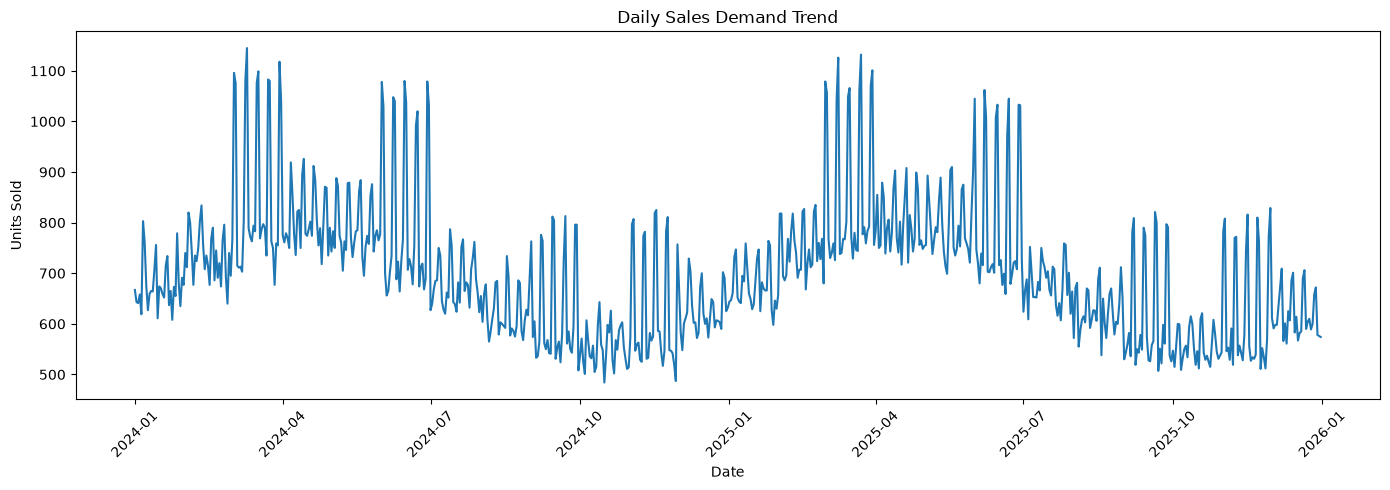

In [19]:
# ============================================
# STEP 5 - OVERALL SALES TREND
# ============================================

import matplotlib.pyplot as plt

# Group daily sales
daily_sales = sales.groupby("Date")["Units_Sold"].sum()

# Plot sales trend
plt.figure(figsize=(14, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

First 10 weeks:
Date
2024-01-07    4793
2024-01-14    4754
2024-01-21    4715
2024-01-28    4696
2024-02-04    5075
2024-02-11    5266
2024-02-18    5150
2024-02-25    5077
2024-03-03    5708
2024-03-10    5870
Freq: W-SUN, Name: Units_Sold, dtype: int64


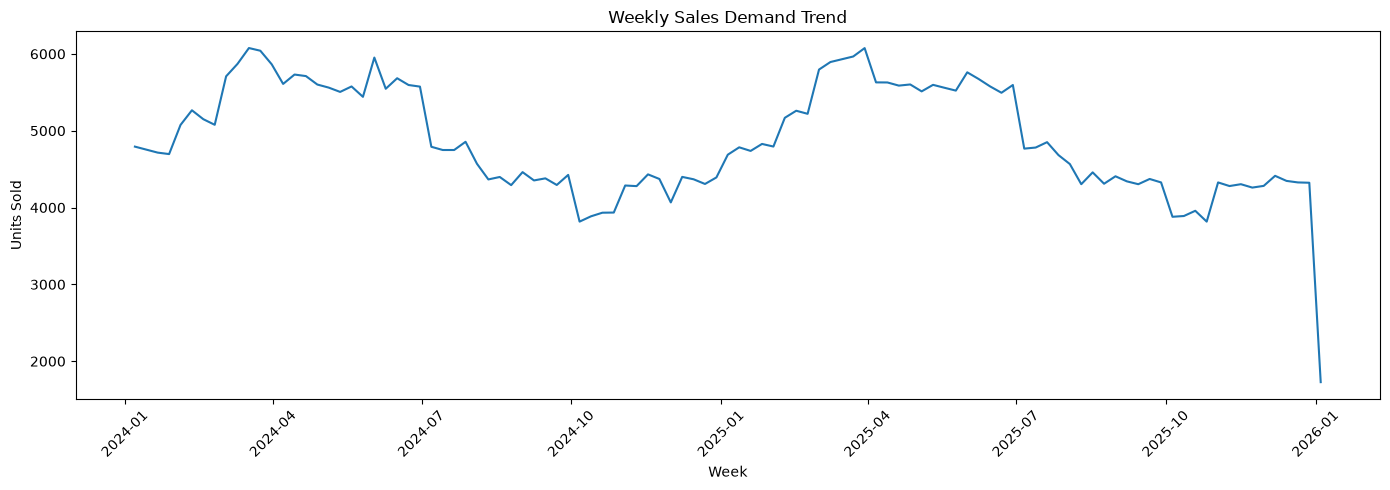

In [20]:
# ============================================
# STEP 5.2 - WEEKLY DEMAND TREND
# ============================================

# Calculate total weekly demand
weekly_sales = (
    sales
    .set_index("Date")["Units_Sold"]
    .resample("W")
    .sum()
)

# Display first 10 weeks
print("First 10 weeks:")
print(weekly_sales.head(10))

# Plot weekly demand
plt.figure(figsize=(14, 5))

plt.plot(weekly_sales.index, weekly_sales.values)

plt.title("Weekly Sales Demand Trend")
plt.xlabel("Week")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

TOP 10 SKUs BY TOTAL UNITS SOLD
-----------------------------------
SKU
SKU012    19067
SKU045    18612
SKU018    18450
SKU049    18373
SKU037    18155
SKU007    18129
SKU027    17717
SKU042    16616
SKU026    16535
SKU043    16276
Name: Units_Sold, dtype: int64


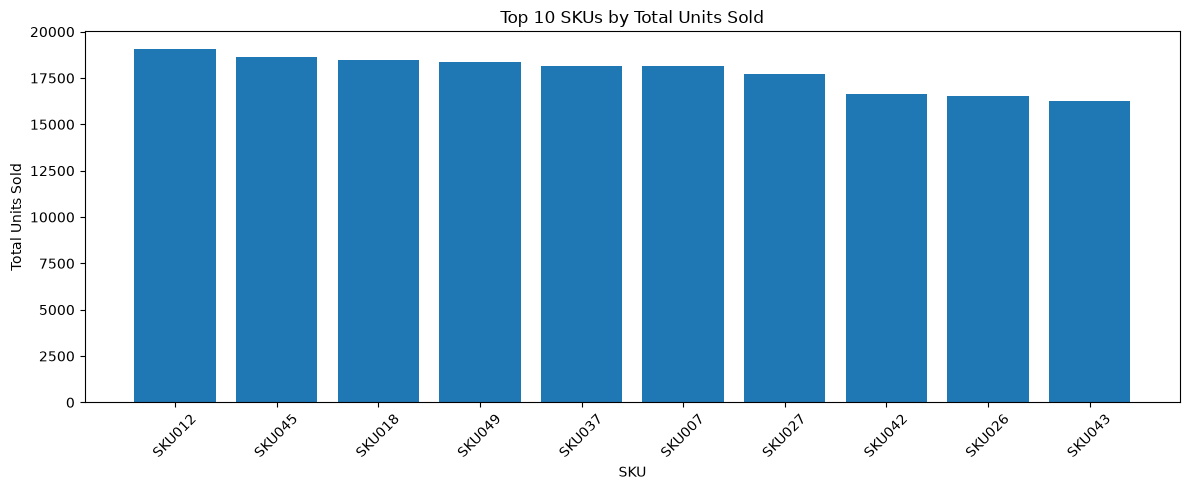

In [21]:
# ============================================
# STEP 5.3 - TOP SELLING SKUs
# ============================================

# Calculate total units sold for each SKU
sku_demand = (
    sales.groupby("SKU")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

# Display top 10 SKUs
print("TOP 10 SKUs BY TOTAL UNITS SOLD")
print("-----------------------------------")
print(sku_demand.head(10))


# Plot top 10 SKUs
top_10 = sku_demand.head(10)

plt.figure(figsize=(12, 5))

plt.bar(top_10.index, top_10.values)

plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

BOTTOM 10 SKUs BY TOTAL UNITS SOLD
-----------------------------------
SKU
SKU011    1951
SKU025    1976
SKU039    2300
SKU015    2994
SKU004    3380
SKU030    3493
SKU036    3508
SKU028    4101
SKU003    4214
SKU050    4537
Name: Units_Sold, dtype: int64


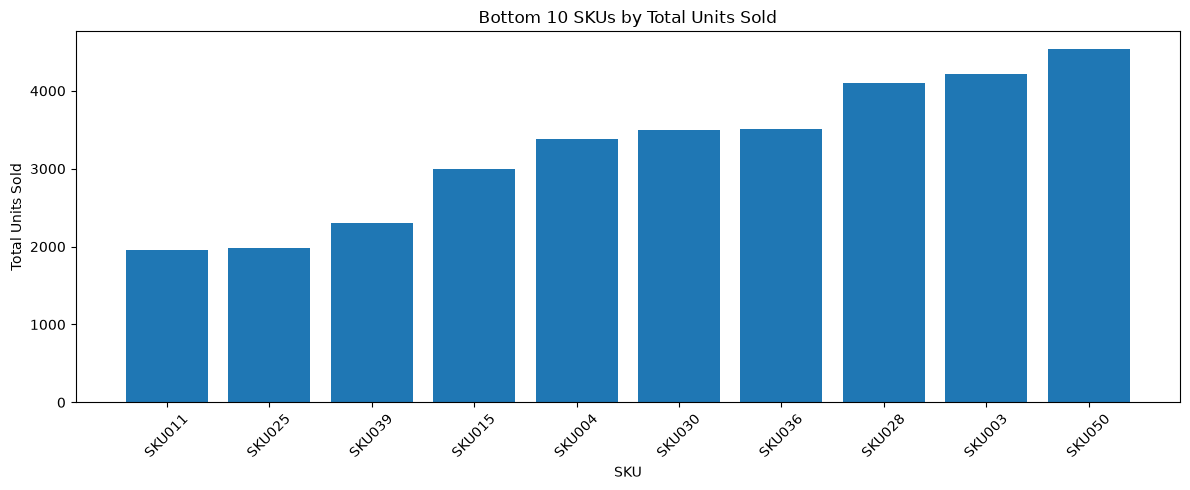

In [22]:
# ============================================
# STEP 5.4 - SLOW-MOVING SKUs
# ============================================

# Total units sold by SKU
sku_demand = (
    sales.groupby("SKU")["Units_Sold"]
    .sum()
    .sort_values()
)

# Bottom 10 SKUs
bottom_10 = sku_demand.head(10)

print("BOTTOM 10 SKUs BY TOTAL UNITS SOLD")
print("-----------------------------------")
print(bottom_10)


# Plot bottom 10 SKUs
plt.figure(figsize=(12, 5))

plt.bar(bottom_10.index, bottom_10.values)

plt.title("Bottom 10 SKUs by Total Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

TOTAL UNITS SOLD BY CATEGORY
-----------------------------------
Category
Home Decor    132570
Lighting      102431
Kitchen       101144
Storage        93367
Furniture      82298
Name: Units_Sold, dtype: int64


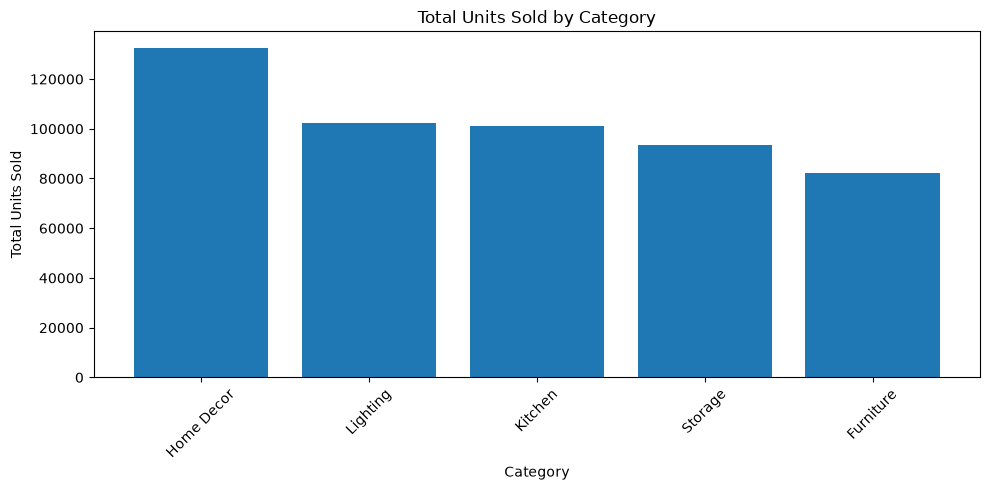

In [23]:
# ============================================
# STEP 5.5 - SALES BY CATEGORY
# ============================================

# Combine sales data with SKU information
sales_with_master = sales.merge(
    sku_master[["SKU", "Category"]],
    on="SKU",
    how="left"
)

# Calculate total units sold by category
category_sales = (
    sales_with_master
    .groupby("Category")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL UNITS SOLD BY CATEGORY")
print("-----------------------------------")
print(category_sales)


# Plot category demand
plt.figure(figsize=(10, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

TOTAL REVENUE BY CATEGORY
-----------------------------------
Category
Home Decor    8.884681e+08
Furniture     6.033905e+08
Storage       5.819274e+08
Kitchen       5.635346e+08
Lighting      4.587362e+08
Name: Revenue, dtype: float64


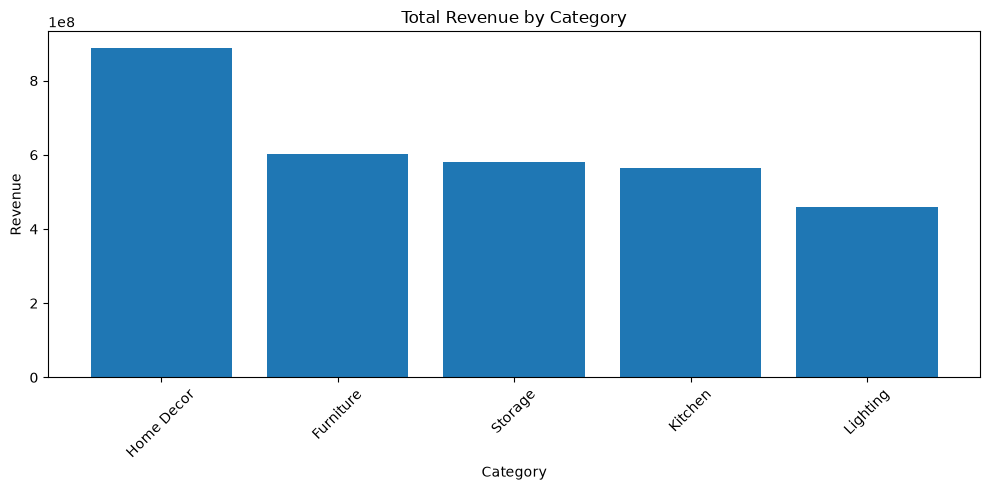

In [24]:
# ============================================
# STEP 5.6 - REVENUE BY CATEGORY
# ============================================

category_revenue = (
    sales_with_master
    .groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL REVENUE BY CATEGORY")
print("-----------------------------------")
print(category_revenue)


# Plot revenue by category
plt.figure(figsize=(10, 5))

plt.bar(category_revenue.index, category_revenue.values)

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

DEMAND BY PROMOTION STATUS
-----------------------------------
                mean     sum  count
Promotion                          
0          13.475945  442011  32800
1          18.613067   69799   3750


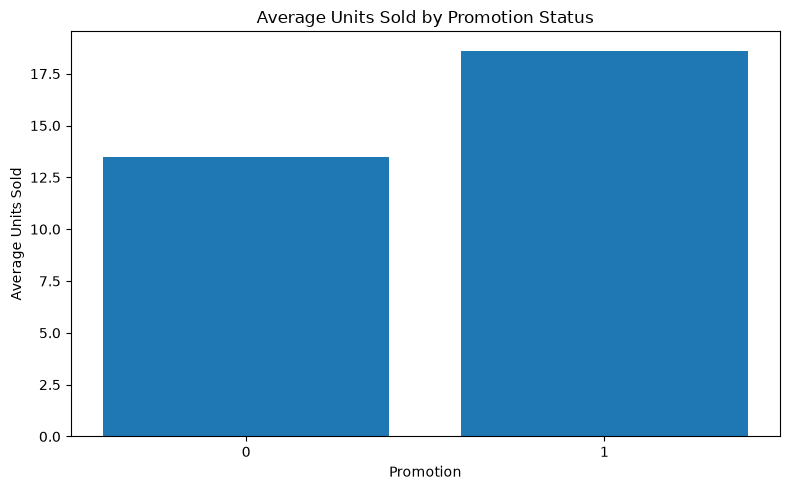

In [25]:
# ============================================
# STEP 5.7 - PROMOTION VS NON-PROMOTION DEMAND
# ============================================

promotion_demand = (
    sales.groupby("Promotion")["Units_Sold"]
    .agg(["mean", "sum", "count"])
)

print("DEMAND BY PROMOTION STATUS")
print("-----------------------------------")
print(promotion_demand)


# Average demand comparison
plt.figure(figsize=(8, 5))

plt.bar(
    promotion_demand.index.astype(str),
    promotion_demand["mean"]
)

plt.title("Average Units Sold by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# STEP 5.8 - INVENTORY OVERVIEW
# ============================================

# Latest inventory snapshot
latest_date = inventory["Snapshot_Date"].max()

latest_inventory = inventory[
    inventory["Snapshot_Date"] == latest_date
].copy()

print("Latest inventory date:", latest_date)

print("\nNumber of SKUs in latest snapshot:")
print(latest_inventory["SKU"].nunique())

print("\nTotal current stock:")
print(latest_inventory["Current_Stock"].sum())

print("\nTotal units on order:")
print(latest_inventory["On_Order"].sum())

print("\nAverage current stock per SKU:")
print(latest_inventory["Current_Stock"].mean())

print("\nAverage reorder point:")
print(latest_inventory["Reorder_Point"].mean())

Latest inventory date: 2025-12-01 00:00:00

Number of SKUs in latest snapshot:
200

Total current stock:
55270

Total units on order:
36577

Average current stock per SKU:
276.35

Average reorder point:
201.865


In [27]:
# ============================================
# STEP 5.8A - VERIFY INVENTORY SNAPSHOTS
# ============================================

print("Total inventory rows:", len(inventory))

print("Unique SKUs:", inventory["SKU"].nunique())

print("Unique snapshot dates:",
      inventory["Snapshot_Date"].nunique())


# How many records exist for each snapshot date?
snapshot_counts = (
    inventory
    .groupby("Snapshot_Date")["SKU"]
    .nunique()
)

print("\nSKUs recorded on each snapshot date:")
print(snapshot_counts)


# Show the first few snapshot dates
print("\nFirst 10 snapshot dates:")
print(snapshot_counts.head(10))


# Show the last 10 snapshot dates
print("\nLast 10 snapshot dates:")
print(snapshot_counts.tail(10))

Total inventory rows: 4800
Unique SKUs: 200
Unique snapshot dates: 24

SKUs recorded on each snapshot date:
Snapshot_Date
2024-01-01    200
2024-02-01    200
2024-03-01    200
2024-04-01    200
2024-05-01    200
2024-06-01    200
2024-07-01    200
2024-08-01    200
2024-09-01    200
2024-10-01    200
2024-11-01    200
2024-12-01    200
2025-01-01    200
2025-02-01    200
2025-03-01    200
2025-04-01    200
2025-05-01    200
2025-06-01    200
2025-07-01    200
2025-08-01    200
2025-09-01    200
2025-10-01    200
2025-11-01    200
2025-12-01    200
Name: SKU, dtype: int64

First 10 snapshot dates:
Snapshot_Date
2024-01-01    200
2024-02-01    200
2024-03-01    200
2024-04-01    200
2024-05-01    200
2024-06-01    200
2024-07-01    200
2024-08-01    200
2024-09-01    200
2024-10-01    200
Name: SKU, dtype: int64

Last 10 snapshot dates:
Snapshot_Date
2025-03-01    200
2025-04-01    200
2025-05-01    200
2025-06-01    200
2025-07-01    200
2025-08-01    200
2025-09-01    200
2025-10-01   

In [28]:
# ============================================
# STEP 5.8B - CHECK SKU MISMATCH
# ============================================

sales_skus = set(sales["SKU"].unique())
master_skus = set(sku_master["SKU"].unique())
inventory_skus = set(inventory["SKU"].unique())

print("Sales SKUs:", len(sales_skus))
print("SKU Master SKUs:", len(master_skus))
print("Inventory SKUs:", len(inventory_skus))

print("\n==========================================")
print("INVENTORY SKUs NOT IN SKU MASTER")
print("==========================================")

inventory_only = sorted(inventory_skus - master_skus)

print("Number of unmatched inventory SKUs:", len(inventory_only))
print("First 20 unmatched SKUs:")
print(inventory_only[:20])


print("\n==========================================")
print("SKUs COMMON TO ALL THREE DATASETS")
print("==========================================")

common_skus = sales_skus & master_skus & inventory_skus

print("Common SKUs:", len(common_skus))
print(sorted(common_skus))

Sales SKUs: 50
SKU Master SKUs: 50
Inventory SKUs: 200

INVENTORY SKUs NOT IN SKU MASTER
Number of unmatched inventory SKUs: 150
First 20 unmatched SKUs:
['SKU051', 'SKU052', 'SKU053', 'SKU054', 'SKU055', 'SKU056', 'SKU057', 'SKU058', 'SKU059', 'SKU060', 'SKU061', 'SKU062', 'SKU063', 'SKU064', 'SKU065', 'SKU066', 'SKU067', 'SKU068', 'SKU069', 'SKU070']

SKUs COMMON TO ALL THREE DATASETS
Common SKUs: 50
['SKU001', 'SKU002', 'SKU003', 'SKU004', 'SKU005', 'SKU006', 'SKU007', 'SKU008', 'SKU009', 'SKU010', 'SKU011', 'SKU012', 'SKU013', 'SKU014', 'SKU015', 'SKU016', 'SKU017', 'SKU018', 'SKU019', 'SKU020', 'SKU021', 'SKU022', 'SKU023', 'SKU024', 'SKU025', 'SKU026', 'SKU027', 'SKU028', 'SKU029', 'SKU030', 'SKU031', 'SKU032', 'SKU033', 'SKU034', 'SKU035', 'SKU036', 'SKU037', 'SKU038', 'SKU039', 'SKU040', 'SKU041', 'SKU042', 'SKU043', 'SKU044', 'SKU045', 'SKU046', 'SKU047', 'SKU048', 'SKU049', 'SKU050']


In [29]:
# ============================================
# STEP 5.9 - FILTER INVENTORY TO VALID SKUs
# ============================================

# Get the SKUs that exist in all required datasets
common_skus = (
    set(sales["SKU"].unique())
    & set(sku_master["SKU"].unique())
    & set(inventory["SKU"].unique())
)

# Create a working inventory dataset
inventory_clean = inventory[
    inventory["SKU"].isin(common_skus)
].copy()

# Sort the data
inventory_clean = inventory_clean.sort_values(
    ["Snapshot_Date", "SKU"]
).reset_index(drop=True)

print("Original inventory rows:", len(inventory))
print("Clean inventory rows:", len(inventory_clean))

print("\nOriginal inventory SKUs:", inventory["SKU"].nunique())
print("Clean inventory SKUs:", inventory_clean["SKU"].nunique())

print("\nClean inventory date range:")
print(
    inventory_clean["Snapshot_Date"].min(),
    "to",
    inventory_clean["Snapshot_Date"].max()
)

Original inventory rows: 4800
Clean inventory rows: 1200

Original inventory SKUs: 200
Clean inventory SKUs: 50

Clean inventory date range:
2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [30]:
# ============================================
# STEP 5.10 - LOW STOCK SKU ANALYSIS
# ============================================

# Get the latest inventory snapshot
latest_date = inventory_clean["Snapshot_Date"].max()

latest_inventory = inventory_clean[
    inventory_clean["Snapshot_Date"] == latest_date
].copy()

# Calculate stock difference from reorder point
latest_inventory["Stock_vs_Reorder"] = (
    latest_inventory["Current_Stock"]
    - latest_inventory["Reorder_Point"]
)

# Identify SKUs below reorder point
low_stock = latest_inventory[
    latest_inventory["Current_Stock"]
    < latest_inventory["Reorder_Point"]
].copy()

# Sort by the biggest shortage
low_stock = low_stock.sort_values(
    "Stock_vs_Reorder"
)

print("Latest inventory date:", latest_date)

print("\nTotal SKUs:", len(latest_inventory))

print("SKUs below reorder point:", len(low_stock))

print("\n========== LOW STOCK SKUs ==========")

print(
    low_stock[
        [
            "SKU",
            "Current_Stock",
            "Reorder_Point",
            "On_Order",
            "Lead_Time_Days",
            "Stock_vs_Reorder"
        ]
    ].to_string(index=False)
)

Latest inventory date: 2025-12-01 00:00:00

Total SKUs: 50
SKUs below reorder point: 14

========== LOW STOCK SKUs ==========
   SKU  Current_Stock  Reorder_Point  On_Order  Lead_Time_Days  Stock_vs_Reorder
SKU037            355            644       687               8              -289
SKU017             95            274        26              12              -179
SKU028            174            337        55              11              -163
SKU015            187            265       245               9               -78
SKU029            261            329       520               5               -68
SKU022             95            163       194               8               -68
SKU009             75            131        89               7               -56
SKU007            207            237       460               8               -30
SKU040             67             93        29               9               -26
SKU034             34             58       103               5  

In [31]:
# Create weekly demand for each SKU

# Make a copy of the sales data
sales_weekly = sales.copy()

# Make sure Date is in date format
sales_weekly["Date"] = pd.to_datetime(
    sales_weekly["Date"],
    errors="coerce"
)

# Create a Week column
sales_weekly["Week"] = (
    sales_weekly["Date"]
    .dt.to_period("W")
    .dt.end_time
    .dt.normalize()
)

# Group daily sales into weekly sales for each SKU
weekly_sku_demand = (
    sales_weekly
    .groupby(["Week", "SKU"], as_index=False)["Units_Sold"]
    .sum()
)

# Sort the data
weekly_sku_demand = (
    weekly_sku_demand
    .sort_values(["SKU", "Week"])
    .reset_index(drop=True)
)

# Display results
print("Weekly SKU dataset created successfully!")
print("Number of rows:", len(weekly_sku_demand))
print("Number of unique SKUs:", weekly_sku_demand["SKU"].nunique())
print("Number of weeks:", weekly_sku_demand["Week"].nunique())
print(
    "Date range:",
    weekly_sku_demand["Week"].min(),
    "to",
    weekly_sku_demand["Week"].max()
)

display(weekly_sku_demand.head(15))

Weekly SKU dataset created successfully!
Number of rows: 5250
Number of unique SKUs: 50
Number of weeks: 105
Date range: 2024-01-07 00:00:00 to 2026-01-04 00:00:00


,Week,SKU,Units_Sold
0,2024-01-07,SKU001,106
1,2024-01-14,SKU001,85
2,2024-01-21,SKU001,117
3,2024-01-28,SKU001,89
4,2024-02-04,SKU001,119
5,2024-02-11,SKU001,112
6,2024-02-18,SKU001,104
7,2024-02-25,SKU001,120
8,2024-03-03,SKU001,103
9,2024-03-10,SKU001,119


In [33]:
# Check weekly SKU data completeness

# Expected number of SKUs
expected_skus = sales["SKU"].nunique()

# Total number of weeks
total_weeks = weekly_sku_demand["Week"].nunique()

# Expected rows if every SKU has data for every week
expected_rows = expected_skus * total_weeks

# Actual rows
actual_rows = len(weekly_sku_demand)

print("Expected number of SKUs:", expected_skus)
print("Number of weeks:", total_weeks)
print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)

if actual_rows == expected_rows:
    print("\n Every SKU has a record for every week.")
else:
    print("\n Some SKU-week combinations are missing.")

Expected number of SKUs: 50
Number of weeks: 105
Expected rows: 5250
Actual rows: 5250

 Every SKU has a record for every week.


In [34]:
# Create Seasonal-Naive baseline
# We use demand from 52 weeks ago as the prediction

baseline = weekly_sku_demand.copy()

# Sort by SKU and Week
baseline = baseline.sort_values(["SKU", "Week"]).reset_index(drop=True)

# Forecast = demand from 52 weeks earlier
baseline["Seasonal_Naive_Forecast"] = (
    baseline.groupby("SKU")["Units_Sold"]
    .shift(52)
)

# Calculate absolute error
baseline["Absolute_Error"] = (
    baseline["Units_Sold"] - baseline["Seasonal_Naive_Forecast"]
).abs()

# Remove rows where a 52-week history is not available
baseline_valid = baseline.dropna(
    subset=["Seasonal_Naive_Forecast"]
).copy()

print("Seasonal-Naive baseline created!")
print("Total rows:", len(baseline))
print("Rows available for evaluation:", len(baseline_valid))

display(baseline_valid.head(15))

Seasonal-Naive baseline created!
Total rows: 5250
Rows available for evaluation: 2650


,Week,SKU,Units_Sold,Seasonal_Naive_Forecast,Absolute_Error
52,2025-01-05,SKU001,78,106.0,28.0
53,2025-01-12,SKU001,100,85.0,15.0
54,2025-01-19,SKU001,89,117.0,28.0
55,2025-01-26,SKU001,103,89.0,14.0
56,2025-02-02,SKU001,100,119.0,19.0
57,2025-02-09,SKU001,106,112.0,6.0
58,2025-02-16,SKU001,124,104.0,20.0
59,2025-02-23,SKU001,116,120.0,4.0
60,2025-03-02,SKU001,111,103.0,8.0
61,2025-03-09,SKU001,98,119.0,21.0


In [35]:
# Calculate WAPE for Seasonal-Naive baseline

total_error = baseline_valid["Absolute_Error"].sum()
total_actual = baseline_valid["Units_Sold"].sum()

wape = total_error / total_actual

print("Seasonal-Naive WAPE:", round(wape * 100, 2), "%")

Seasonal-Naive WAPE: 11.76 %


In [36]:
# Step 7.1 - Create demand lag features

features = weekly_sku_demand.copy()

# Sort data
features = features.sort_values(["SKU", "Week"]).reset_index(drop=True)

# Previous week demand
features["Lag_1"] = (
    features.groupby("SKU")["Units_Sold"].shift(1)
)

# Demand 2 weeks ago
features["Lag_2"] = (
    features.groupby("SKU")["Units_Sold"].shift(2)
)

# Demand 4 weeks ago
features["Lag_4"] = (
    features.groupby("SKU")["Units_Sold"].shift(4)
)

# Demand 52 weeks ago
features["Lag_52"] = (
    features.groupby("SKU")["Units_Sold"].shift(52)
)

print("Lag features created successfully!")

display(features.head(15))

Lag features created successfully!


,Week,SKU,Units_Sold,Lag_1,Lag_2,Lag_4,Lag_52
0,2024-01-07,SKU001,106,NaN,NaN,NaN,NaN
1,2024-01-14,SKU001,85,106.0,NaN,NaN,NaN
2,2024-01-21,SKU001,117,85.0,106.0,NaN,NaN
3,2024-01-28,SKU001,89,117.0,85.0,NaN,NaN
4,2024-02-04,SKU001,119,89.0,117.0,106.0,NaN
5,2024-02-11,SKU001,112,119.0,89.0,85.0,NaN
6,2024-02-18,SKU001,104,112.0,119.0,117.0,NaN
7,2024-02-25,SKU001,120,104.0,112.0,89.0,NaN
8,2024-03-03,SKU001,103,120.0,104.0,119.0,NaN
9,2024-03-10,SKU001,119,103.0,120.0,112.0,NaN


In [37]:
# Step 7.2 - Create rolling demand features

# 4-week average demand
features["Rolling_4_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

# 8-week average demand
features["Rolling_8_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

print("Rolling features created successfully!")

display(
    features[
        [
            "Week",
            "SKU",
            "Units_Sold",
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Lag_52",
            "Rolling_4_Week",
            "Rolling_8_Week"
        ]
    ].head(15)
)

Rolling features created successfully!


,Week,SKU,Units_Sold,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_4_Week,Rolling_8_Week
0,2024-01-07,SKU001,106,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-14,SKU001,85,106.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-21,SKU001,117,85.0,106.0,NaN,NaN,NaN,NaN
3,2024-01-28,SKU001,89,117.0,85.0,NaN,NaN,NaN,NaN
4,2024-02-04,SKU001,119,89.0,117.0,106.0,NaN,99.25,NaN
5,2024-02-11,SKU001,112,119.0,89.0,85.0,NaN,102.50,NaN
6,2024-02-18,SKU001,104,112.0,119.0,117.0,NaN,109.25,NaN
7,2024-02-25,SKU001,120,104.0,112.0,89.0,NaN,106.00,NaN
8,2024-03-03,SKU001,103,120.0,104.0,119.0,NaN,113.75,106.500
9,2024-03-10,SKU001,119,103.0,120.0,112.0,NaN,109.75,106.125


In [10]:
import pandas as pd

sales = pd.read_csv("../data/raw/sales_daily.csv")

sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)

print("Sales data loaded:", sales.shape)

Sales data loaded: (36550, 6)


In [11]:
# Create weekly demand for each SKU

sales_weekly = sales.copy()

sales_weekly["Week"] = (
    sales_weekly["Date"]
    .dt.to_period("W")
    .dt.end_time
    .dt.normalize()
)

weekly_sku_demand = (
    sales_weekly
    .groupby(["Week", "SKU"], as_index=False)["Units_Sold"]
    .sum()
)

weekly_sku_demand = (
    weekly_sku_demand
    .sort_values(["SKU", "Week"])
    .reset_index(drop=True)
)

print("Weekly SKU demand created!")
print("Rows:", len(weekly_sku_demand))
print("Unique SKUs:", weekly_sku_demand["SKU"].nunique())
print("Weeks:", weekly_sku_demand["Week"].nunique())

display(weekly_sku_demand.head(10))

Weekly SKU demand created!
Rows: 5250
Unique SKUs: 50
Weeks: 105


,Week,SKU,Units_Sold
0,2024-01-07,SKU001,106
1,2024-01-14,SKU001,85
2,2024-01-21,SKU001,117
3,2024-01-28,SKU001,89
4,2024-02-04,SKU001,119
5,2024-02-11,SKU001,112
6,2024-02-18,SKU001,104
7,2024-02-25,SKU001,120
8,2024-03-03,SKU001,103
9,2024-03-10,SKU001,119


In [12]:
features = weekly_sku_demand.copy()

features = features.sort_values(
    ["SKU", "Week"]
).reset_index(drop=True)

features["Lag_1"] = features.groupby("SKU")["Units_Sold"].shift(1)
features["Lag_2"] = features.groupby("SKU")["Units_Sold"].shift(2)
features["Lag_4"] = features.groupby("SKU")["Units_Sold"].shift(4)
features["Lag_52"] = features.groupby("SKU")["Units_Sold"].shift(52)

features["Rolling_4_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

features["Rolling_8_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

print("Features created successfully!")

display(features.head(10))

Features created successfully!


,Week,SKU,Units_Sold,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_4_Week,Rolling_8_Week
0,2024-01-07,SKU001,106,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-14,SKU001,85,106.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-21,SKU001,117,85.0,106.0,NaN,NaN,NaN,NaN
3,2024-01-28,SKU001,89,117.0,85.0,NaN,NaN,NaN,NaN
4,2024-02-04,SKU001,119,89.0,117.0,106.0,NaN,99.25,NaN
5,2024-02-11,SKU001,112,119.0,89.0,85.0,NaN,102.50,NaN
6,2024-02-18,SKU001,104,112.0,119.0,117.0,NaN,109.25,NaN
7,2024-02-25,SKU001,120,104.0,112.0,89.0,NaN,106.00,NaN
8,2024-03-03,SKU001,103,120.0,104.0,119.0,NaN,113.75,106.500
9,2024-03-10,SKU001,119,103.0,120.0,112.0,NaN,109.75,106.125


In [13]:
# Remove rows with missing feature values

features_clean = features.dropna(
    subset=[
        "Lag_1",
        "Lag_2",
        "Lag_4",
        "Lag_52",
        "Rolling_4_Week",
        "Rolling_8_Week"
    ]
).copy()

features_clean = features_clean.reset_index(drop=True)

print("Feature dataset prepared successfully!")
print("Original rows:", len(features))
print("Clean rows:", len(features_clean))
print("Rows removed:", len(features) - len(features_clean))

display(features_clean.head(10))

Feature dataset prepared successfully!
Original rows: 5250
Clean rows: 2650
Rows removed: 2600


,Week,SKU,Units_Sold,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_4_Week,Rolling_8_Week
0,2025-01-05,SKU001,78,105.0,77.0,83.0,106.0,89.75,86.750
1,2025-01-12,SKU001,100,78.0,105.0,94.0,85.0,88.50,84.125
2,2025-01-19,SKU001,89,100.0,78.0,77.0,117.0,90.00,86.625
3,2025-01-26,SKU001,103,89.0,100.0,105.0,89.0,93.00,86.750
4,2025-02-02,SKU001,100,103.0,89.0,78.0,119.0,92.50,91.125
5,2025-02-09,SKU001,106,100.0,103.0,100.0,112.0,98.00,93.250
6,2025-02-16,SKU001,124,106.0,100.0,89.0,104.0,99.50,94.750
7,2025-02-23,SKU001,116,124.0,106.0,103.0,120.0,108.25,100.625
8,2025-03-02,SKU001,111,116.0,124.0,100.0,103.0,111.50,102.000
9,2025-03-09,SKU001,98,111.0,116.0,106.0,119.0,114.25,106.125


In [14]:
# Step 8.1 - Create time-based training and testing data

# Find the latest week in the dataset
latest_week = features_clean["Week"].max()

# Use the latest 12 weeks as testing data
test_start_week = latest_week - pd.Timedelta(weeks=11)

# Training data: before the test period
train_data = features_clean[
    features_clean["Week"] < test_start_week
].copy()

# Testing data: latest 12 weeks
test_data = features_clean[
    features_clean["Week"] >= test_start_week
].copy()

print("Training and testing datasets created!")
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))
print("Training date range:", train_data["Week"].min(), "to", train_data["Week"].max())
print("Testing date range:", test_data["Week"].min(), "to", test_data["Week"].max())

Training and testing datasets created!
Training rows: 2050
Testing rows: 600
Training date range: 2025-01-05 00:00:00 to 2025-10-12 00:00:00
Testing date range: 2025-10-19 00:00:00 to 2026-01-04 00:00:00


In [15]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\nagaj\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("scikit-learn imported successfully!")
# Select input features and target variable

feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_52",
    "Rolling_4_Week",
    "Rolling_8_Week"
]

X_train = train_data[feature_columns]
y_train = train_data["Units_Sold"]

X_test = test_data[feature_columns]
y_test = test_data["Units_Sold"]

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)

scikit-learn imported successfully!
Training input shape: (2050, 6)
Testing input shape: (600, 6)


In [18]:
# Train the Random Forest forecasting model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
# Generate predictions for the testing period

y_pred = model.predict(X_test)

# Avoid negative demand predictions
y_pred = y_pred.clip(min=0)

print("Predictions generated successfully!")

display(
    pd.DataFrame({
        "Actual_Demand": y_test.values,
        "Predicted_Demand": y_pred
    }).head(15)
)

Predictions generated successfully!


,Actual_Demand,Predicted_Demand
0,82,86.62
1,78,85.94
2,93,79.48
3,92,88.81
4,87,82.16
5,84,79.69
6,84,78.43
7,88,78.46
8,89,86.92
9,91,81.70


In [21]:
# Calculate WAPE for the Random Forest model

absolute_error = abs(y_test.values - y_pred)

model_wape = absolute_error.sum() / y_test.sum()

print("Random Forest WAPE:", round(model_wape * 100, 2), "%")
print("Seasonal-Naive WAPE: 11.76 %")

if model_wape < 0.1176:
    print(" The Random Forest model beats the baseline!")
else:
    print(" The Random Forest model does not beat the baseline yet.")

Random Forest WAPE: 15.5 %
Seasonal-Naive WAPE: 11.76 %
 The Random Forest model does not beat the baseline yet.


In [23]:
import pandas as pd

calendar = pd.read_csv("../data/raw/calendar.csv")

print("Calendar loaded successfully!")
print("Shape:", calendar.shape)
print("Columns:", calendar.columns.tolist())

display(calendar.head())

Calendar loaded successfully!
Shape: (731, 11)
Columns: ['date', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'season', 'holiday', 'is_holiday', 'promotion_event']


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


In [2]:
import pandas as pd

print("Pandas imported successfully!")

Pandas imported successfully!


In [4]:
calendar = pd.read_csv("../data/raw/calendar.csv")

print("Calendar loaded successfully!")
print(calendar.columns.tolist())

Calendar loaded successfully!
['date', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'season', 'holiday', 'is_holiday', 'promotion_event']


In [6]:
print("Calendar weekly shape:", calendar_weekly.shape)
print("Calendar weekly columns:", calendar_weekly.columns.tolist())

display(calendar_weekly.head(10))

Calendar weekly shape: (105, 3)
Calendar weekly columns: ['Week', 'Promotion_Event', 'Holiday_Count']


,Week,Promotion_Event,Holiday_Count
0,2024-01-07,0.0,0
1,2024-01-14,0.0,0
2,2024-01-21,0.0,0
3,2024-01-28,0.0,1
4,2024-02-04,0.0,0
5,2024-02-11,0.0,0
6,2024-02-18,0.0,0
7,2024-02-25,0.0,0
8,2024-03-03,0.0,0
9,2024-03-10,0.0,0


In [7]:
# Merge weekly demand with weekly calendar information

weekly_sku_demand_calendar = weekly_sku_demand.merge(
    calendar_weekly,
    on="Week",
    how="left"
)

# Fill missing calendar values with zero
weekly_sku_demand_calendar["Promotion_Event"] = (
    weekly_sku_demand_calendar["Promotion_Event"].fillna(0)
)

weekly_sku_demand_calendar["Holiday_Count"] = (
    weekly_sku_demand_calendar["Holiday_Count"].fillna(0)
)

print("Weekly demand and calendar data merged successfully!")

print(
    "Rows:",
    len(weekly_sku_demand_calendar)
)

print(
    "Columns:",
    weekly_sku_demand_calendar.columns.tolist()
)

display(weekly_sku_demand_calendar.head(10))

NameError: name 'weekly_sku_demand' is not defined

In [8]:
import pandas as pd

sales = pd.read_csv("../data/raw/sales_daily.csv")

sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)

print("Sales loaded:", sales.shape)

Sales loaded: (36550, 6)


In [9]:
sales_weekly = sales.copy()

sales_weekly["Week"] = (
    sales_weekly["Date"]
    .dt.to_period("W")
    .dt.end_time
    .dt.normalize()
)

weekly_sku_demand = (
    sales_weekly
    .groupby(["Week", "SKU"], as_index=False)["Units_Sold"]
    .sum()
)

weekly_sku_demand = (
    weekly_sku_demand
    .sort_values(["SKU", "Week"])
    .reset_index(drop=True)
)

print("Weekly SKU demand recreated!")
print("Rows:", len(weekly_sku_demand))
print("SKUs:", weekly_sku_demand["SKU"].nunique())

Weekly SKU demand recreated!
Rows: 5250
SKUs: 50


In [10]:
weekly_sku_demand_calendar = weekly_sku_demand.merge(
    calendar_weekly,
    on="Week",
    how="left"
)

weekly_sku_demand_calendar["Promotion_Event"] = (
    weekly_sku_demand_calendar["Promotion_Event"].fillna(0)
)

weekly_sku_demand_calendar["Holiday_Count"] = (
    weekly_sku_demand_calendar["Holiday_Count"].fillna(0)
)

print("Merge completed successfully!")

display(weekly_sku_demand_calendar.head(10))

Merge completed successfully!


,Week,SKU,Units_Sold,Promotion_Event,Holiday_Count
0,2024-01-07,SKU001,106,0.0,0
1,2024-01-14,SKU001,85,0.0,0
2,2024-01-21,SKU001,117,0.0,0
3,2024-01-28,SKU001,89,0.0,1
4,2024-02-04,SKU001,119,0.0,0
5,2024-02-11,SKU001,112,0.0,0
6,2024-02-18,SKU001,104,0.0,0
7,2024-02-25,SKU001,120,0.0,0
8,2024-03-03,SKU001,103,0.0,0
9,2024-03-10,SKU001,119,0.0,0


In [11]:
print("Merged dataset shape:", weekly_sku_demand_calendar.shape)

print(
    "Merged dataset columns:",
    weekly_sku_demand_calendar.columns.tolist()
)

print(
    "Missing calendar values:",
    weekly_sku_demand_calendar[
        ["Promotion_Event", "Holiday_Count"]
    ].isna().sum().to_dict()
)

display(weekly_sku_demand_calendar.head(10))

Merged dataset shape: (5250, 5)
Merged dataset columns: ['Week', 'SKU', 'Units_Sold', 'Promotion_Event', 'Holiday_Count']
Missing calendar values: {'Promotion_Event': 0, 'Holiday_Count': 0}


,Week,SKU,Units_Sold,Promotion_Event,Holiday_Count
0,2024-01-07,SKU001,106,0.0,0
1,2024-01-14,SKU001,85,0.0,0
2,2024-01-21,SKU001,117,0.0,0
3,2024-01-28,SKU001,89,0.0,1
4,2024-02-04,SKU001,119,0.0,0
5,2024-02-11,SKU001,112,0.0,0
6,2024-02-18,SKU001,104,0.0,0
7,2024-02-25,SKU001,120,0.0,0
8,2024-03-03,SKU001,103,0.0,0
9,2024-03-10,SKU001,119,0.0,0


In [12]:
# Create the final forecasting features

features = weekly_sku_demand_calendar.copy()

# Sort by SKU and week
features = features.sort_values(
    ["SKU", "Week"]
).reset_index(drop=True)

# Lag features
features["Lag_1"] = features.groupby("SKU")["Units_Sold"].shift(1)
features["Lag_2"] = features.groupby("SKU")["Units_Sold"].shift(2)
features["Lag_4"] = features.groupby("SKU")["Units_Sold"].shift(4)
features["Lag_52"] = features.groupby("SKU")["Units_Sold"].shift(52)

# Rolling averages
features["Rolling_4_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

features["Rolling_8_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

print("Final forecasting features created!")

print("Columns:")
print(features.columns.tolist())

display(features.head(10))

Final forecasting features created!
Columns:
['Week', 'SKU', 'Units_Sold', 'Promotion_Event', 'Holiday_Count', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_52', 'Rolling_4_Week', 'Rolling_8_Week']


,Week,SKU,Units_Sold,Promotion_Event,Holiday_Count,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_4_Week,Rolling_8_Week
0,2024-01-07,SKU001,106,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-14,SKU001,85,0.0,0,106.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-21,SKU001,117,0.0,0,85.0,106.0,NaN,NaN,NaN,NaN
3,2024-01-28,SKU001,89,0.0,1,117.0,85.0,NaN,NaN,NaN,NaN
4,2024-02-04,SKU001,119,0.0,0,89.0,117.0,106.0,NaN,99.25,NaN
5,2024-02-11,SKU001,112,0.0,0,119.0,89.0,85.0,NaN,102.50,NaN
6,2024-02-18,SKU001,104,0.0,0,112.0,119.0,117.0,NaN,109.25,NaN
7,2024-02-25,SKU001,120,0.0,0,104.0,112.0,89.0,NaN,106.00,NaN
8,2024-03-03,SKU001,103,0.0,0,120.0,104.0,119.0,NaN,113.75,106.500
9,2024-03-10,SKU001,119,0.0,0,103.0,120.0,112.0,NaN,109.75,106.125


In [13]:
# Remove rows with missing forecasting features

required_features = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_52",
    "Rolling_4_Week",
    "Rolling_8_Week"
]

features_clean = features.dropna(
    subset=required_features
).copy()

features_clean = features_clean.reset_index(drop=True)

print("Final feature dataset prepared!")
print("Original rows:", len(features))
print("Clean rows:", len(features_clean))
print("Rows removed:", len(features) - len(features_clean))

display(features_clean.head(10))

Final feature dataset prepared!
Original rows: 5250
Clean rows: 2650
Rows removed: 2600


,Week,SKU,Units_Sold,Promotion_Event,Holiday_Count,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_4_Week,Rolling_8_Week
0,2025-01-05,SKU001,78,0.0,0,105.0,77.0,83.0,106.0,89.75,86.750
1,2025-01-12,SKU001,100,0.0,0,78.0,105.0,94.0,85.0,88.50,84.125
2,2025-01-19,SKU001,89,0.0,0,100.0,78.0,77.0,117.0,90.00,86.625
3,2025-01-26,SKU001,103,0.0,1,89.0,100.0,105.0,89.0,93.00,86.750
4,2025-02-02,SKU001,100,0.0,0,103.0,89.0,78.0,119.0,92.50,91.125
5,2025-02-09,SKU001,106,0.0,0,100.0,103.0,100.0,112.0,98.00,93.250
6,2025-02-16,SKU001,124,0.0,0,106.0,100.0,89.0,104.0,99.50,94.750
7,2025-02-23,SKU001,116,0.0,0,124.0,106.0,103.0,120.0,108.25,100.625
8,2025-03-02,SKU001,111,0.0,0,116.0,124.0,100.0,103.0,111.50,102.000
9,2025-03-09,SKU001,98,0.0,0,111.0,116.0,106.0,119.0,114.25,106.125


In [14]:
# Create time-based training and testing datasets

latest_week = features_clean["Week"].max()

# Use the latest 12 weeks for testing
test_start_week = latest_week - pd.Timedelta(weeks=11)

train_data = features_clean[
    features_clean["Week"] < test_start_week
].copy()

test_data = features_clean[
    features_clean["Week"] >= test_start_week
].copy()

print("Training and testing datasets created!")

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print(
    "Training date range:",
    train_data["Week"].min(),
    "to",
    train_data["Week"].max()
)

print(
    "Testing date range:",
    test_data["Week"].min(),
    "to",
    test_data["Week"].max()
)

Training and testing datasets created!
Training rows: 2050
Testing rows: 600
Training date range: 2025-01-05 00:00:00 to 2025-10-12 00:00:00
Testing date range: 2025-10-19 00:00:00 to 2026-01-04 00:00:00


In [15]:
# Select demand and calendar features

feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_52",
    "Rolling_4_Week",
    "Rolling_8_Week",
    "Promotion_Event",
    "Holiday_Count"
]

X_train = train_data[feature_columns]
y_train = train_data["Units_Sold"]

X_test = test_data[feature_columns]
y_test = test_data["Units_Sold"]

print("Updated model inputs created!")
print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)
print("Number of features:", len(feature_columns))

Updated model inputs created!
Training input shape: (2050, 8)
Testing input shape: (600, 8)
Number of features: 8


In [2]:
import numpy as np
import pandas as pd
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn is working")

NumPy: 2.5.2
Pandas: 3.0.5
scikit-learn is working


In [5]:
import pandas as pd
import numpy as np

# Load the original CSV files
sales = pd.read_csv("../data/raw/sales_daily.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")

# Convert dates
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")

# Prepare promotion information
calendar["promotion_event"] = (
    calendar["promotion_event"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "nan": "0",
        "none": "0",
        "": "0",
        "yes": "1",
        "true": "1",
        "no": "0",
        "false": "0"
    })
)

calendar["promotion_event"] = pd.to_numeric(
    calendar["promotion_event"],
    errors="coerce"
).fillna(0)

calendar["is_holiday"] = pd.to_numeric(
    calendar["is_holiday"],
    errors="coerce"
).fillna(0)

# Convert daily sales into weekly SKU demand
sales["Week"] = (
    sales["Date"]
    .dt.to_period("W")
    .dt.end_time
    .dt.normalize()
)

weekly_sku_demand = (
    sales.groupby(["Week", "SKU"], as_index=False)["Units_Sold"]
    .sum()
)

# Convert calendar information into weekly information
calendar["Week"] = (
    calendar["date"]
    .dt.to_period("W")
    .dt.end_time
    .dt.normalize()
)

calendar_weekly = (
    calendar.groupby("Week", as_index=False)
    .agg(
        Promotion_Event=("promotion_event", "max"),
        Holiday_Count=("is_holiday", "sum")
    )
)

# Merge sales and calendar information
weekly_sku_demand_calendar = weekly_sku_demand.merge(
    calendar_weekly,
    on="Week",
    how="left"
)

weekly_sku_demand_calendar["Promotion_Event"] = (
    weekly_sku_demand_calendar["Promotion_Event"].fillna(0)
)

weekly_sku_demand_calendar["Holiday_Count"] = (
    weekly_sku_demand_calendar["Holiday_Count"].fillna(0)
)

# Sort the data
features = (
    weekly_sku_demand_calendar
    .sort_values(["SKU", "Week"])
    .reset_index(drop=True)
)

# Create lag features
features["Lag_1"] = (
    features.groupby("SKU")["Units_Sold"].shift(1)
)

features["Lag_2"] = (
    features.groupby("SKU")["Units_Sold"].shift(2)
)

features["Lag_4"] = (
    features.groupby("SKU")["Units_Sold"].shift(4)
)

features["Lag_52"] = (
    features.groupby("SKU")["Units_Sold"].shift(52)
)

# Create rolling-average features
features["Rolling_4_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

features["Rolling_8_Week"] = (
    features.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

# Remove rows with missing feature values
features_clean = features.dropna(
    subset=[
        "Lag_1",
        "Lag_2",
        "Lag_4",
        "Lag_52",
        "Rolling_4_Week",
        "Rolling_8_Week"
    ]
).reset_index(drop=True)

print("Weekly demand rows:", len(weekly_sku_demand))
print("Feature rows:", len(features_clean))
print("Feature columns:", features_clean.columns.tolist())

Weekly demand rows: 5250
Feature rows: 2650
Feature columns: ['Week', 'SKU', 'Units_Sold', 'Promotion_Event', 'Holiday_Count', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_52', 'Rolling_4_Week', 'Rolling_8_Week']


In [6]:
# Create training and testing datasets

feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_52",
    "Rolling_4_Week",
    "Rolling_8_Week",
    "Promotion_Event",
    "Holiday_Count"
]

latest_week = features_clean["Week"].max()

# Use the latest 12 weeks as testing data
test_start_week = latest_week - pd.Timedelta(weeks=11)

train_data = features_clean[
    features_clean["Week"] < test_start_week
].copy()

test_data = features_clean[
    features_clean["Week"] >= test_start_week
].copy()

X_train = train_data[feature_columns]
y_train = train_data["Units_Sold"]

X_test = test_data[feature_columns]
y_test = test_data["Units_Sold"]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training rows: 2050
Testing rows: 600
X_train shape: (2050, 8)
X_test shape: (600, 8)


In [7]:
from sklearn.ensemble import RandomForestRegressor

improved_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

improved_model.fit(X_train, y_train)

print("Improved Random Forest model trained successfully")

Improved Random Forest model trained successfully


In [8]:
# Generate predictions
improved_pred = improved_model.predict(X_test)

# Prevent negative demand predictions
improved_pred = np.maximum(improved_pred, 0)

print("Predictions generated successfully")

Predictions generated successfully


In [9]:
# Calculate Improved Random Forest WAPE

absolute_error = np.abs(y_test.values - improved_pred)

improved_wape = (
    absolute_error.sum() / y_test.sum()
)

print("Improved Random Forest WAPE:",
      round(improved_wape * 100, 2), "%")

print("Seasonal-Naive WAPE: 11.76 %")

if improved_wape < 0.1176:
    print("Result: Random Forest performed better than the baseline.")
else:
    print("Result: Seasonal-Naive performed better than Random Forest.")

Improved Random Forest WAPE: 15.47 %
Seasonal-Naive WAPE: 11.76 %
Result: Seasonal-Naive performed better than Random Forest.


In [10]:
# Calculate Seasonal-Naive WAPE on the same test period

test_baseline = test_data.copy()

test_baseline["Seasonal_Naive_Forecast"] = (
    test_baseline["Lag_52"]
)

test_baseline = test_baseline.dropna(
    subset=["Seasonal_Naive_Forecast"]
)

baseline_absolute_error = np.abs(
    test_baseline["Units_Sold"]
    - test_baseline["Seasonal_Naive_Forecast"]
)

same_period_baseline_wape = (
    baseline_absolute_error.sum()
    / test_baseline["Units_Sold"].sum()
)

print(
    "Seasonal-Naive WAPE on same test period:",
    round(same_period_baseline_wape * 100, 2),
    "%"
)

print(
    "Random Forest WAPE:",
    round(improved_wape * 100, 2),
    "%"
)

Seasonal-Naive WAPE on same test period: 17.31 %
Random Forest WAPE: 15.47 %


In [11]:
# Save model comparison results

model_results = pd.DataFrame({
    "Model": [
        "Seasonal-Naive",
        "Random Forest"
    ],
    "WAPE": [
        same_period_baseline_wape * 100,
        improved_wape * 100
    ]
})

model_results

,Model,WAPE
0,Seasonal-Naive,17.307613
1,Random Forest,15.469555


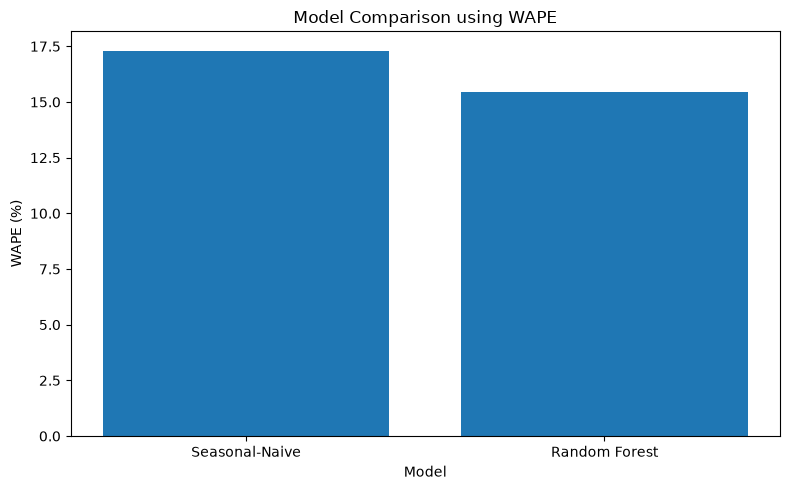

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["WAPE"]
)

plt.title("Model Comparison using WAPE")
plt.xlabel("Model")
plt.ylabel("WAPE (%)")

plt.tight_layout()
plt.show()

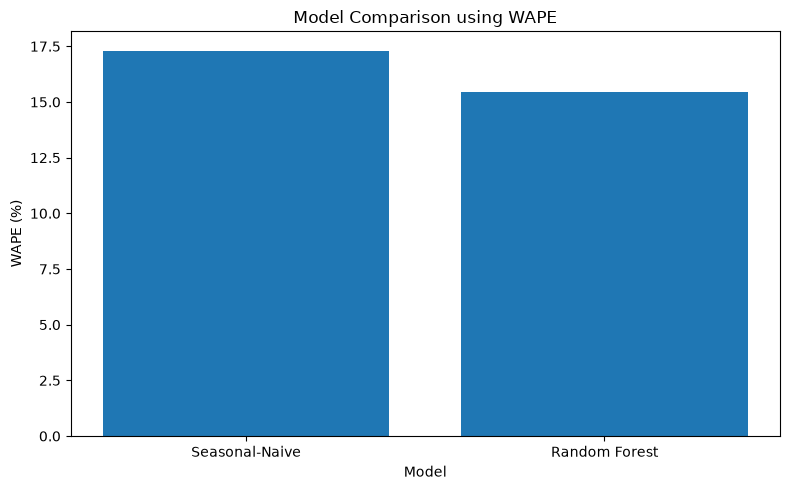

Chart saved successfully.


In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["WAPE"]
)

plt.title("Model Comparison using WAPE")
plt.xlabel("Model")
plt.ylabel("WAPE (%)")

plt.tight_layout()

plt.savefig(
    "../reports/model_comparison_wape.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

In [14]:
import joblib

joblib.dump(
    improved_model,
    "../reports/random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [15]:
# Load inventory data

inventory = pd.read_csv("../data/raw/inventory_snapshots.csv")

inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"],
    errors="coerce"
)

print("Inventory shape:", inventory.shape)
print("Inventory columns:")
print(inventory.columns.tolist())

inventory.head()

Inventory shape: (4800, 8)
Inventory columns:
['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value']


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89


In [16]:
# Select the latest inventory date

latest_inventory_date = inventory["Snapshot_Date"].max()

latest_inventory = inventory[
    inventory["Snapshot_Date"] == latest_inventory_date
].copy()

print("Latest inventory date:", latest_inventory_date)
print("Latest inventory rows:", len(latest_inventory))

latest_inventory.head()

Latest inventory date: 2025-12-01 00:00:00
Latest inventory rows: 200


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
4600,2025-12-01,SKU001,771,147,4,159,289,2815160.01
4601,2025-12-01,SKU002,526,29,3,94,149,2974319.60
4602,2025-12-01,SKU003,349,12,3,88,123,2145941.67
4603,2025-12-01,SKU004,259,254,6,98,196,321905.92
4604,2025-12-01,SKU005,471,291,6,129,245,3500674.53


In [17]:
# Calculate basic inventory indicators

latest_inventory["Available_Stock"] = (
    latest_inventory["Current_Stock"]
    + latest_inventory["On_Order"]
)

latest_inventory["Stock_Gap"] = (
    latest_inventory["Current_Stock"]
    - latest_inventory["Reorder_Point"]
)

latest_inventory["Reorder_Status"] = np.where(
    latest_inventory["Current_Stock"]
    < latest_inventory["Reorder_Point"],
    "Below Reorder Point",
    "Healthy Stock"
)

print(
    latest_inventory["Reorder_Status"]
    .value_counts()
)

latest_inventory[
    [
        "SKU",
        "Current_Stock",
        "On_Order",
        "Reorder_Point",
        "Available_Stock",
        "Stock_Gap",
        "Reorder_Status"
    ]
].head(10)

Reorder_Status
Healthy Stock          139
Below Reorder Point     61
Name: count, dtype: int64


,SKU,Current_Stock,On_Order,Reorder_Point,Available_Stock,Stock_Gap,Reorder_Status
4600,SKU001,771,147,289,918,482,Healthy Stock
4601,SKU002,526,29,149,555,377,Healthy Stock
4602,SKU003,349,12,123,361,226,Healthy Stock
4603,SKU004,259,254,196,513,63,Healthy Stock
4604,SKU005,471,291,245,762,226,Healthy Stock
4605,SKU006,359,485,340,844,19,Healthy Stock
4606,SKU007,207,460,237,667,-30,Below Reorder Point
4607,SKU008,325,155,161,480,164,Healthy Stock
4608,SKU009,75,89,131,164,-56,Below Reorder Point
4609,SKU010,83,70,60,153,23,Healthy Stock


In [18]:
# Keep only SKUs available in the sales dataset

project_skus = sales["SKU"].unique()

latest_inventory_project = latest_inventory[
    latest_inventory["SKU"].isin(project_skus)
].copy()

print("Project SKUs:", len(project_skus))
print(
    "Inventory rows after filtering:",
    len(latest_inventory_project)
)

print(
    latest_inventory_project["Reorder_Status"].value_counts()
)

Project SKUs: 50
Inventory rows after filtering: 50
Reorder_Status
Healthy Stock          36
Below Reorder Point    14
Name: count, dtype: int64


In [19]:
print("Project SKUs:", len(project_skus))
print("Filtered inventory rows:", len(latest_inventory_project))

print("\nReorder status:")
print(latest_inventory_project["Reorder_Status"].value_counts())

Project SKUs: 50
Filtered inventory rows: 50

Reorder status:
Reorder_Status
Healthy Stock          36
Below Reorder Point    14
Name: count, dtype: int64


In [20]:
# Calculate average weekly demand for each SKU

average_weekly_demand = (
    weekly_sku_demand
    .groupby("SKU")["Units_Sold"]
    .mean()
    .reset_index(name="Average_Weekly_Demand")
)

average_weekly_demand.head()

,SKU,Average_Weekly_Demand
0,SKU001,100.019048
1,SKU002,70.590476
2,SKU003,40.133333
3,SKU004,32.190476
4,SKU005,116.152381


In [21]:
# Calculate lead-time demand

risk_data = latest_inventory_project.merge(
    average_weekly_demand,
    on="SKU",
    how="left"
)

# Convert weekly demand into daily demand
risk_data["Average_Daily_Demand"] = (
    risk_data["Average_Weekly_Demand"] / 7
)

# Estimate demand during the lead time
risk_data["Lead_Time_Demand"] = (
    risk_data["Average_Daily_Demand"]
    * risk_data["Lead_Time_Days"]
)

# Calculate stock available after expected lead-time demand
risk_data["Projected_Stock_After_Lead_Time"] = (
    risk_data["Current_Stock"]
    + risk_data["On_Order"]
    - risk_data["Lead_Time_Demand"]
)

risk_data[
    [
        "SKU",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Lead_Time_Demand",
        "Projected_Stock_After_Lead_Time"
    ]
].head(10)

,SKU,Current_Stock,On_Order,Lead_Time_Days,Lead_Time_Demand,Projected_Stock_After_Lead_Time
0,SKU001,771,147,4,57.153741,860.846259
1,SKU002,526,29,3,30.253061,524.746939
2,SKU003,349,12,3,17.200000,343.800000
3,SKU004,259,254,6,27.591837,485.408163
4,SKU005,471,291,6,99.559184,662.440816
5,SKU006,359,485,13,84.650340,759.349660
6,SKU007,207,460,8,197.322449,469.677551
7,SKU008,325,155,3,48.751020,431.248980
8,SKU009,75,89,7,74.571429,89.428571
9,SKU010,83,70,13,220.398639,-67.398639


In [22]:
# Assign stockout risk levels

risk_data["Stockout_Risk"] = np.where(
    risk_data["Projected_Stock_After_Lead_Time"] < 0,
    "High",
    np.where(
        risk_data["Projected_Stock_After_Lead_Time"]
        < risk_data["Safety_Stock"],
        "Medium",
        "Low"
    )
)

print(risk_data["Stockout_Risk"].value_counts())

risk_data[
    [
        "SKU",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Demand",
        "Safety_Stock",
        "Projected_Stock_After_Lead_Time",
        "Stockout_Risk"
    ]
].head(10)

Stockout_Risk
Low       44
High       5
Medium     1
Name: count, dtype: int64


,SKU,Current_Stock,On_Order,Lead_Time_Demand,Safety_Stock,Projected_Stock_After_Lead_Time,Stockout_Risk
0,SKU001,771,147,57.153741,159,860.846259,Low
1,SKU002,526,29,30.253061,94,524.746939,Low
2,SKU003,349,12,17.200000,88,343.800000,Low
3,SKU004,259,254,27.591837,98,485.408163,Low
4,SKU005,471,291,99.559184,129,662.440816,Low
5,SKU006,359,485,84.650340,129,759.349660,Low
6,SKU007,207,460,197.322449,98,469.677551,Low
7,SKU008,325,155,48.751020,91,431.248980,Low
8,SKU009,75,89,74.571429,63,89.428571,Low
9,SKU010,83,70,220.398639,22,-67.398639,High


In [23]:
# Calculate estimated demand for the next 4 weeks

risk_data["Four_Week_Demand"] = (
    risk_data["Average_Weekly_Demand"] * 4
)

# Calculate excess stock after covering 4 weeks of demand
risk_data["Excess_Stock"] = (
    risk_data["Current_Stock"]
    - risk_data["Four_Week_Demand"]
)

# Assign overstock-risk levels
risk_data["Overstock_Risk"] = np.where(
    risk_data["Excess_Stock"] > risk_data["Safety_Stock"] * 2,
    "High",
    np.where(
        risk_data["Excess_Stock"] > risk_data["Safety_Stock"],
        "Medium",
        "Low"
    )
)

print(risk_data["Overstock_Risk"].value_counts())

risk_data[
    [
        "SKU",
        "Current_Stock",
        "Four_Week_Demand",
        "Excess_Stock",
        "Safety_Stock",
        "Overstock_Risk"
    ]
].head(10)

Overstock_Risk
Low       39
High       8
Medium     3
Name: count, dtype: int64


,SKU,Current_Stock,Four_Week_Demand,Excess_Stock,Safety_Stock,Overstock_Risk
0,SKU001,771,400.076190,370.923810,159,High
1,SKU002,526,282.361905,243.638095,94,High
2,SKU003,349,160.533333,188.466667,88,High
3,SKU004,259,128.761905,130.238095,98,Medium
4,SKU005,471,464.609524,6.390476,129,Low
5,SKU006,359,182.323810,176.676190,129,Medium
6,SKU007,207,690.628571,-483.628571,98,Low
7,SKU008,325,455.009524,-130.009524,91,Low
8,SKU009,75,298.285714,-223.285714,63,Low
9,SKU010,83,474.704762,-391.704762,22,Low


In [24]:
print("Overstock risk counts:")
print(risk_data["Overstock_Risk"].value_counts())

print("\nHighest excess-stock SKUs:")

risk_data[
    [
        "SKU",
        "Current_Stock",
        "Four_Week_Demand",
        "Excess_Stock",
        "Safety_Stock",
        "Overstock_Risk"
    ]
].sort_values(
    "Excess_Stock",
    ascending=False
).head(10)

Overstock risk counts:
Overstock_Risk
Low       39
High       8
Medium     3
Name: count, dtype: int64

Highest excess-stock SKUs:


,SKU,Current_Stock,Four_Week_Demand,Excess_Stock,Safety_Stock,Overstock_Risk
24,SKU025,1124,75.276190,1048.723810,121,High
10,SKU011,753,74.323810,678.676190,179,High
19,SKU020,1002,386.209524,615.790476,129,High
0,SKU001,771,400.076190,370.923810,159,High
35,SKU036,383,133.638095,249.361905,77,High
1,SKU002,526,282.361905,243.638095,94,High
2,SKU003,349,160.533333,188.466667,88,High
5,SKU006,359,182.323810,176.676190,129,Medium
49,SKU050,328,172.838095,155.161905,69,High
3,SKU004,259,128.761905,130.238095,98,Medium


In [25]:
# Create an initial inventory action recommendation

risk_data["Recommended_Action"] = np.select(
    [
        risk_data["Stockout_Risk"] == "High",
        risk_data["Overstock_Risk"] == "High",
        risk_data["Stockout_Risk"] == "Medium",
        risk_data["Overstock_Risk"] == "Medium"
    ],
    [
        "Reorder Now",
        "Review Markdown/Clearance",
        "Monitor Stockout Risk",
        "Review Excess Stock"
    ],
    default="Healthy"
)

print(risk_data["Recommended_Action"].value_counts())

risk_data[
    [
        "SKU",
        "Stockout_Risk",
        "Overstock_Risk",
        "Recommended_Action"
    ]
].head(10)

Recommended_Action
Healthy                      33
Review Markdown/Clearance     8
Reorder Now                   5
Review Excess Stock           3
Monitor Stockout Risk         1
Name: count, dtype: int64


,SKU,Stockout_Risk,Overstock_Risk,Recommended_Action
0,SKU001,Low,High,Review Markdown/Clearance
1,SKU002,Low,High,Review Markdown/Clearance
2,SKU003,Low,High,Review Markdown/Clearance
3,SKU004,Low,Medium,Review Excess Stock
4,SKU005,Low,Low,Healthy
5,SKU006,Low,Medium,Review Excess Stock
6,SKU007,Low,Low,Healthy
7,SKU008,Low,Low,Healthy
8,SKU009,Low,Low,Healthy
9,SKU010,High,Low,Reorder Now


In [26]:
# Estimate the rupee value associated with excess stock

risk_data["Excess_Stock_Units"] = (
    risk_data["Excess_Stock"].clip(lower=0)
)

risk_data["Estimated_Excess_Value"] = (
    risk_data["Excess_Stock_Units"]
    * (
        risk_data["Inventory_Value"]
        / risk_data["Current_Stock"].replace(0, np.nan)
    )
)

risk_data["Estimated_Excess_Value"] = (
    risk_data["Estimated_Excess_Value"].fillna(0)
)

print(
    "Total estimated excess inventory value: ₹",
    round(risk_data["Estimated_Excess_Value"].sum(), 2)
)

risk_data[
    [
        "SKU",
        "Excess_Stock_Units",
        "Estimated_Excess_Value",
        "Overstock_Risk"
    ]
].sort_values(
    "Estimated_Excess_Value",
    ascending=False
).head(10)

Total estimated excess inventory value: ₹ 18186756.89


,SKU,Excess_Stock_Units,Estimated_Excess_Value,Overstock_Risk
24,SKU025,1048.723810,4.091072e+06,High
19,SKU020,615.790476,3.411073e+06,High
10,SKU011,678.676190,2.624502e+06,High
1,SKU002,243.638095,1.377676e+06,High
0,SKU001,370.923810,1.354358e+06,High
5,SKU006,176.676190,1.170727e+06,Medium
2,SKU003,188.466667,1.158849e+06,High
40,SKU041,129.409524,7.341053e+05,Medium
49,SKU050,155.161905,5.388013e+05,High
34,SKU035,77.161905,4.512644e+05,Low


In [27]:
# Save the inventory risk report

risk_report_columns = [
    "SKU",
    "Current_Stock",
    "On_Order",
    "Lead_Time_Days",
    "Safety_Stock",
    "Reorder_Point",
    "Average_Weekly_Demand",
    "Lead_Time_Demand",
    "Projected_Stock_After_Lead_Time",
    "Stockout_Risk",
    "Four_Week_Demand",
    "Excess_Stock_Units",
    "Overstock_Risk",
    "Recommended_Action",
    "Inventory_Value",
    "Estimated_Excess_Value"
]

risk_report = risk_data[risk_report_columns].copy()

risk_report.to_csv(
    "../reports/inventory_risk_report.csv",
    index=False
)

print("Inventory risk report saved successfully.")
print("Rows saved:", len(risk_report))

Inventory risk report saved successfully.
Rows saved: 50


In [28]:
forecast_results = test_data[
    ["Week", "SKU", "Units_Sold"]
].copy()

forecast_results["Random_Forest_Forecast"] = improved_pred

forecast_results["Seasonal_Naive_Forecast"] = (
    features_clean.loc[
        test_data.index, "Lag_52"
    ].values
)

forecast_results = forecast_results.rename(
    columns={"Units_Sold": "Actual_Demand"}
)

forecast_results.to_csv(
    "../reports/forecast_results.csv",
    index=False
)

print("Forecast results saved successfully.")
print("Rows saved:", len(forecast_results))
display(forecast_results.head())

Forecast results saved successfully.
Rows saved: 600


,Week,SKU,Actual_Demand,Random_Forest_Forecast,Seasonal_Naive_Forecast
41,2025-10-19,SKU001,82,86.250,88.0
42,2025-10-26,SKU001,78,86.920,89.0
43,2025-11-02,SKU001,93,78.140,83.0
44,2025-11-09,SKU001,92,89.985,99.0
45,2025-11-16,SKU001,87,81.670,80.0


In [29]:
import os

print("Inventory risk report exists:",
      os.path.exists("../reports/inventory_risk_report.csv"))

print("Forecast results exists:",
      os.path.exists("../reports/forecast_results.csv"))

print("\nFiles inside reports folder:")
print(os.listdir("../reports"))

Inventory risk report exists: True
Forecast results exists: True

Files inside reports folder:
['forecast_results.csv', 'inventory_risk_report.csv', 'model_comparison_wape.png', 'random_forest_model.pkl']


In [30]:
# Load SKU master data again
sku_master = pd.read_csv("../data/raw/sku_master.csv")

# Load saved reports
forecast_results = pd.read_csv("../reports/forecast_results.csv")
risk_report = pd.read_csv("../reports/inventory_risk_report.csv")

# Keep the latest forecast record for each SKU
latest_forecast = (
    forecast_results
    .sort_values("Week")
    .groupby("SKU", as_index=False)
    .tail(1)
)

# Combine inventory risk with SKU information
dashboard_data = risk_report.merge(
    sku_master,
    on="SKU",
    how="left"
)

# Add the latest forecast information
dashboard_data = dashboard_data.merge(
    latest_forecast[
        ["SKU", "Week", "Actual_Demand",
         "Random_Forest_Forecast",
         "Seasonal_Naive_Forecast"]
    ],
    on="SKU",
    how="left"
)

# Save dashboard dataset
dashboard_data.to_csv(
    "../reports/dashboard_data.csv",
    index=False
)

print("Dashboard dataset created successfully.")
print("Rows:", len(dashboard_data))
print("Columns:", len(dashboard_data.columns))

display(dashboard_data.head())

Dashboard dataset created successfully.
Rows: 50
Columns: 27


,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Average_Weekly_Demand,Lead_Time_Demand,Projected_Stock_After_Lead_Time,Stockout_Risk,...,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit,Week,Actual_Demand,Random_Forest_Forecast,Seasonal_Naive_Forecast
0,SKU001,771,147,4,159,289,100.019048,57.153741,860.846259,Low,...,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60,2026-01-04,37,84.660,78.0
1,SKU002,526,29,3,94,149,70.590476,30.253061,524.746939,Low,...,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40,2026-01-04,27,61.130,70.0
2,SKU003,349,12,3,88,123,40.133333,17.200000,343.800000,Low,...,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75,2026-01-04,17,35.240,32.0
3,SKU004,259,254,6,98,196,32.190476,27.591837,485.408163,Low,...,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83,2026-01-04,6,30.160,37.0
4,SKU005,471,291,6,129,245,116.152381,99.559184,662.440816,Low,...,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59,2026-01-04,50,104.835,111.0
